In [9]:
import math
import numpy as np
import random
from matplotlib import pyplot as plt
from pedestrian import *
from scipy.signal import welch, detrend, butter, filtfilt
from solver import* #Phi_matrix ,accdyn_super,MatrixAssemblesymetric,calculate_frf_and_accelerance,g_pj
from matrix import bridge


#step 1 setup beam and pedestrians

#beam

length = 50  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq =2 #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2
numbers = 2

#ped
numped = 1
pedmass =70      #kg
peddamp = .3    
#pedstiff = 25000 #N/m
pedpace  = 2     #Hz
pedphase = 0
pedInlocation = 0
pedvelocity = 1.25
pedBodyF= 2 #Hz


modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12

#set time info
hht=0.01

#initial possition vector.......formultiple ped all these would become matrices

#xrb=np.zeros(1,numped)
xrb=[0]

Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers =numbers  )                   #modes


N_bridge = 2


# Number of Monte Carlo simulations
num_simulations = 50

# PSD parameters
fs = 1 / 0.01  # Sampling frequency (inverse of time step)
nperseg = 1024  # Segment length for Welch's method
noverlap = nperseg // 2  # Overlap for Welch's method
nfft = 4096  # Number of FFT points for high frequency resolution

# Initialize a list to accumulate PSDs
all_psds = []


# probabilitstic parameters
mean_pace = 2 #Hz  2005 pachi
pace_COV = 0.1

# Monte Carlo Simulation loop
for sim in range(num_simulations):
    # Generate random variables for pedestrian
    randomPace = random.gauss(mean_pace, pace_COV*mean_pace)
    # Time vector
    t = np.arange(0, (length + 1) / pedvelocity, hht)

    # Create Bridge and Pedestrian instances
    Bridge = bridge(length, E * width * height**3 / 12, linearMass, modalDampingRatio, numbers)
    kped1 = (2 * np.pi * beamFreq)**2 * pedmass
    cped1 = (2 * np.pi * beamFreq) * 2 * peddamp * pedmass

    mped = np.array([pedmass])
    cped = np.array([cped1])
    kped = np.array([kped1])
    
    Human = Pedestrian(
        mass=pedmass,
        damp=modalDampingRatio,
        stiff=kped,
        pace=randomPace,
        phase=0,
        location=0,
        velocity=pedvelocity,
        iSync=0
    )
   # Initialize the modal force matrix
    F = np.zeros((numbers, len(t))) 

    # Compute modal force for each time step
    xr = np.array([0])
    for i in range(len(t)):
        # Calculate the pedestrian force at time t
        force_at_time_t = calcDynamicPedForce(Human, t[i])
        # Compute the mode shape (NN)
        NN = Phi_matrix(xr, length, linearMass, numbers, numped).flatten()  
        # Compute modal force
        F[:, i] = (linearMass * length / 2) ** 0.5 * NN * force_at_time_t
        # Update the pedestrian position
        xr = np.add(xr, pedvelocity * 0.01)

    # Compute the PSD of the modal force using Welch's method (for the first mode)
    frequencies, psd = welch(F[0, :], fs=fs, nperseg=nperseg, noverlap=noverlap, nfft=nfft)

    # Accumulate PSD values (sum them up)
    all_psds.append(psd)

# Compute the mean PSD across all simulations
mean_psd = np.mean(all_psds, axis=0)



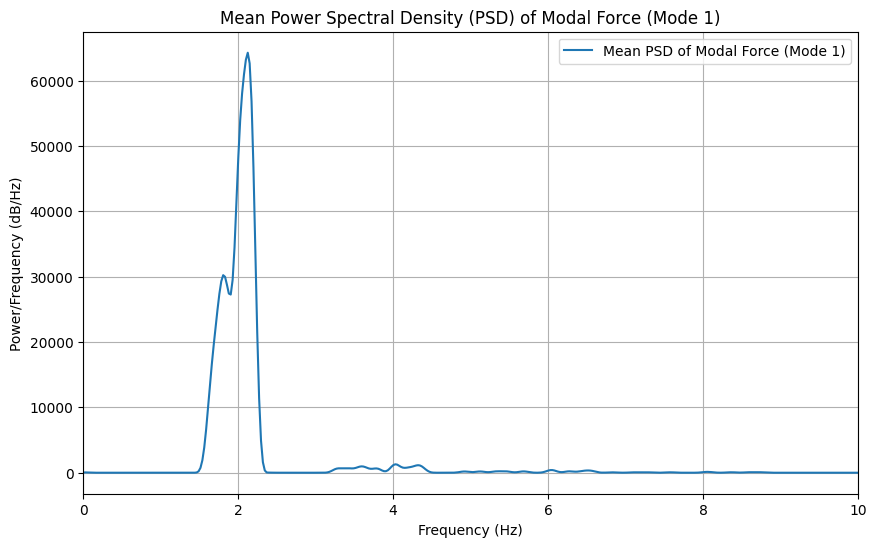

In [8]:

# Plot the mean PSD of the modal force
plt.figure(figsize=(10, 6))
plt.plot(frequencies, mean_psd, label='Mean PSD of Modal Force (Mode 1)')
plt.xlim(0, 10)  # Adjust frequency range as needed
plt.title('Mean Power Spectral Density (PSD) of Modal Force (Mode 1)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power/Frequency (dB/Hz)')
plt.grid(True)
plt.legend()
plt.show()